# Cat vs Dog Classification with ANN (From Scratch)

This notebook implements a pure Artificial Neural Network (ANN) from scratch for classifying cats and dogs using the Hugging Face dataset `microsoft/cats_vs_dogs`.

**Note**: This uses a simple ANN (flattened images), not CNN. For image tasks, CNN is recommended, but this demonstrates ANN from scratch.

**Key Features:**
- Pure ANN (no pretrained models, no CNN)
- Data augmentation to prevent overfitting
- Early stopping and learning rate scheduling
- Target: >80% validation accuracy

In [1]:
# Install required packages
# !pip install datasets torchvision matplotlib numpy pandas

In [2]:
# Cat vs Dog with pure ANN (no pretrained model)

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, ImageFile

# Hugging Face datasets
from datasets import load_dataset

# Allow loading slightly corrupted/truncated images
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [3]:
# -----------------------------
# 1) Reproducibility and device
# -----------------------------

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [4]:
# -----------------------------
# 2) Load dataset from Hugging Face
# -----------------------------

print("Loading dataset from Hugging Face: microsoft/cats_vs_dogs")
dataset = load_dataset("microsoft/cats_vs_dogs")

# Split into train and validation (80% train, 20% validation)
train_val_split = dataset["train"].train_test_split(test_size=0.2, seed=SEED)
train_dataset = train_val_split["train"]
val_dataset = train_val_split["test"]

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Loading dataset from Hugging Face: microsoft/cats_vs_dogs


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/330M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/391M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/23410 [00:00<?, ? examples/s]

Train samples: 18728
Validation samples: 4682



Class distribution (train):
  class 0 (cat): 9406
  class 1 (dog): 9322

Class distribution (val):
  class 0 (cat): 2335
  class 1 (dog): 2347


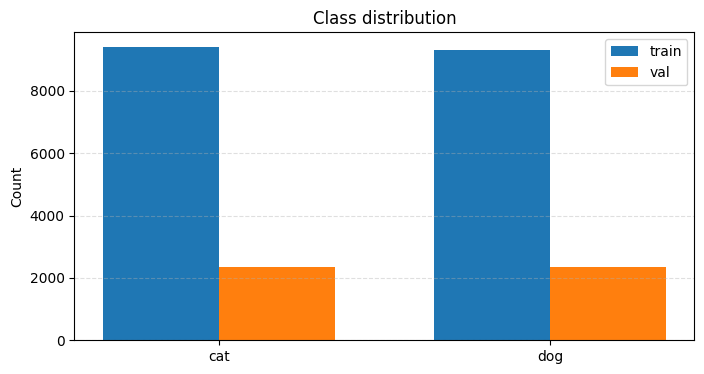

In [5]:
# -----------------------------
# 3) Data analysis
# -----------------------------

# Count class distribution
train_labels = [sample["labels"] for sample in train_dataset]
val_labels = [sample["labels"] for sample in val_dataset]

train_counts = np.bincount(train_labels, minlength=2)
val_counts = np.bincount(val_labels, minlength=2)

class_names = {0: "cat", 1: "dog"}

print("\nClass distribution (train):")
for k in range(2):
    print(f"  class {k} ({class_names[k]}): {train_counts[k]}")

print("\nClass distribution (val):")
for k in range(2):
    print(f"  class {k} ({class_names[k]}): {val_counts[k]}")

# Plot class distribution
plt.figure(figsize=(8, 4))
x = np.array([0, 1])
w = 0.35
plt.bar(x - w / 2, train_counts, width=w, label="train")
plt.bar(x + w / 2, val_counts, width=w, label="val")
plt.xticks(x, ["cat", "dog"])
plt.ylabel("Count")
plt.title("Class distribution")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

In [6]:
# -----------------------------
# 4) Dataset configuration
# -----------------------------

# Smaller image size for ANN (flattening a large image creates too many features)
IMG_SIZE = 64
BATCH_SIZE = 128
NUM_WORKERS = 0

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Transform for ANN - resize and normalize
train_tfms = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ]
)

val_tfms = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ]
)

In [7]:
# -----------------------------
# 5) Custom Dataset class for Hugging Face data
# -----------------------------


class HFCatDogDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        sample = self.hf_dataset[idx]
        image = sample["image"]
        label = sample["labels"]

        # Convert to RGB if needed
        if image.mode != "RGB":
            image = image.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        # Flatten for ANN: (3, 64, 64) -> (3 * 64 * 64,) = 12288
        image = image.view(-1)

        return image, torch.tensor(label, dtype=torch.float32)


# Create datasets
train_ds = HFCatDogDataset(train_dataset, train_tfms)
val_ds = HFCatDogDataset(val_dataset, val_tfms)

print(f"Flattened feature size: {IMG_SIZE * IMG_SIZE * 3}")

Flattened feature size: 12288


In [8]:
# -----------------------------
# 6) DataLoader
# -----------------------------

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

print(f"Number of batches - Train: {len(train_loader)}, Val: {len(val_loader)}")

Number of batches - Train: 147, Val: 37


In [9]:
# -----------------------------
# 7) Pure ANN model (from scratch)
# -----------------------------

# Input: 64x64x3 = 12288 features
INPUT_SIZE = IMG_SIZE * IMG_SIZE * 3


class CatDogANN(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            # Hidden layer 1
            nn.Linear(input_size, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            # Hidden layer 2
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            # Hidden layer 3
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            # Output layer
            nn.Linear(512, 1),
        )

    def forward(self, x):
        return self.network(x)


model = CatDogANN(INPUT_SIZE).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-6
)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 27,798,529


In [10]:
# -----------------------------
# 8) Training loop
# -----------------------------

EPOCHS = 30
PATIENCE = 5
best_val_acc = 0.0
best_state = None
no_improve = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}


def run_one_epoch(loader, train_mode=True):
    if train_mode:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).unsqueeze(1)

        with torch.set_grad_enabled(train_mode):
            logits = model(images)
            loss = criterion(logits, labels)

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)
                optimizer.step()

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        running_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / max(total, 1)
    epoch_acc = correct / max(total, 1)
    return epoch_loss, epoch_acc


print("Starting training...")
for epoch in range(EPOCHS):
    train_loss, train_acc = run_one_epoch(train_loader, train_mode=True)
    val_loss, val_acc = run_one_epoch(val_loader, train_mode=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    scheduler.step(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(
                f"Early stopping at epoch {epoch+1} (no val acc improvement for {PATIENCE} epochs)"
            )
            break

    # Clear GPU cache periodically
    if device.type == "cuda" and (epoch + 1) % 5 == 0:
        torch.cuda.empty_cache()

if best_state is not None:
    model.load_state_dict(best_state)

Starting training...
Epoch 01/30 | Train Loss: 0.6718, Train Acc: 59.80% | Val Loss: 0.6515, Val Acc: 61.02%
Epoch 02/30 | Train Loss: 0.6358, Train Acc: 63.44% | Val Loss: 0.6410, Val Acc: 62.75%
Epoch 03/30 | Train Loss: 0.6256, Train Acc: 64.66% | Val Loss: 0.6281, Val Acc: 63.80%
Epoch 04/30 | Train Loss: 0.6148, Train Acc: 65.73% | Val Loss: 0.6238, Val Acc: 64.97%
Epoch 05/30 | Train Loss: 0.6088, Train Acc: 66.38% | Val Loss: 0.6156, Val Acc: 65.46%
Epoch 06/30 | Train Loss: 0.6051, Train Acc: 66.43% | Val Loss: 0.6120, Val Acc: 66.19%
Epoch 07/30 | Train Loss: 0.5978, Train Acc: 67.23% | Val Loss: 0.6179, Val Acc: 66.13%
Epoch 08/30 | Train Loss: 0.5913, Train Acc: 67.59% | Val Loss: 0.6104, Val Acc: 66.45%
Epoch 09/30 | Train Loss: 0.5899, Train Acc: 67.86% | Val Loss: 0.6074, Val Acc: 66.19%
Epoch 10/30 | Train Loss: 0.5849, Train Acc: 68.54% | Val Loss: 0.6136, Val Acc: 66.23%
Epoch 11/30 | Train Loss: 0.5807, Train Acc: 68.88% | Val Loss: 0.6079, Val Acc: 66.40%
Epoch 12/30

In [11]:
# -----------------------------
# 9) Final evaluation
# -----------------------------

val_loss, val_acc = run_one_epoch(val_loader, train_mode=False)
print(f"\nBest/Final validation accuracy: {val_acc*100:.2f}%")

# Calculate confusion matrix
tp = tn = fp = fn = 0
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device).long()
        logits = model(images)
        preds = (torch.sigmoid(logits).squeeze(1) >= 0.5).long()

        tp += int(((preds == 1) & (labels == 1)).sum().item())
        tn += int(((preds == 0) & (labels == 0)).sum().item())
        fp += int(((preds == 1) & (labels == 0)).sum().item())
        fn += int(((preds == 0) & (labels == 1)).sum().item())

precision = tp / max(tp + fp, 1)
recall = tp / max(tp + fn, 1)
f1 = 2 * precision * recall / max(precision + recall, 1e-8)

print("\nConfusion matrix counts:")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")


Best/Final validation accuracy: 69.46%

Confusion matrix counts:
TN=1631, FP=704, FN=726, TP=1621
Precision: 0.6972 | Recall: 0.6907 | F1: 0.6939


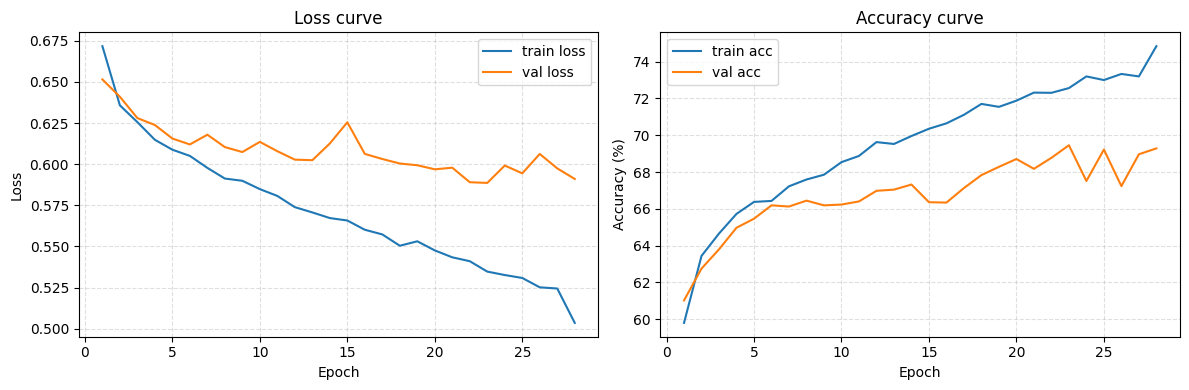

In [12]:
# -----------------------------
# 10) Plot training history
# -----------------------------

epochs_ran = len(history["train_loss"])
x = np.arange(1, epochs_ran + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x, history["train_loss"], label="train loss")
plt.plot(x, history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curve")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.subplot(1, 2, 2)
plt.plot(x, np.array(history["train_acc"]) * 100, label="train acc")
plt.plot(x, np.array(history["val_acc"]) * 100, label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy curve")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [13]:
# -----------------------------
# 11) Save model
# -----------------------------

save_path = "catdog_ann_best.pth"
torch.save(model.state_dict(), save_path)
print(f"Saved best model to: {save_path}")

if val_acc >= 0.80:
    print("Target reached: validation accuracy >= 80%")
else:
    print(
        "Validation accuracy < 80%. ANN on images is limited - consider using CNN for better results."
    )

Saved best model to: catdog_ann_best.pth
Validation accuracy < 80%. ANN on images is limited - consider using CNN for better results.


## Summary

This notebook demonstrates:
1. **Pure ANN Architecture**: No CNN, no pretrained models
2. **Hugging Face Dataset**: Uses `microsoft/cats_vs_dogs`
3. **Anti-overfitting Techniques**:
   - Data augmentation (RandomHorizontalFlip, RandomRotation, ColorJitter)
   - Dropout layers (0.4, 0.3, 0.2)
   - Batch normalization
   - Weight decay (L2 regularization)
   - Early stopping
   - Learning rate scheduling
   - Gradient clipping
4. **Note**: ANN on flattened images has limited capacity for image tasks. CNN is recommended for better accuracy.